# Learn Probability Density Functions using Roll-Number-Parameterized Non-Linear Model

**Dataset:** India Air Quality Data (NO2 feature)  
**Link:** https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data

## Objective
1. Transform NO2 data using roll-number-parameterized function
2. Learn parameters (λ, μ, c) of the PDF: $p(z) = c \cdot e^{-\lambda(z-\mu)^2}$
3. Submit the learned parameters

In [1]:
# Import required libraries
import numpy as npy
import pandas as pds
import matplotlib.pyplot as plotter
from scipy.optimize import minimize as opt_minimize, curve_fit as fit_curve
from scipy.integrate import quad as integrate_quad
import seaborn as sb   

# Set plotting style
sb.set_style('whitegrid')
plotter.rcParams['figure.figsize'] = (12, 8)

# Set random seed
npy.random.seed(42)

## Step 0: Configuration - Enter Your Roll Number

In [2]:
STUDENT_ID = 102317137

# Calculate transformation parameters
alpha_param = 0.05 * (STUDENT_ID % 7)
beta_param = 0.3 * (STUDENT_ID % 5 + 1)

print(f"Roll Number: {STUDENT_ID}")
print(f"ar = 0.05 × ({STUDENT_ID} mod 7) = {alpha_param:.6f}")
print(f"br = 0.3 × ({STUDENT_ID} mod 5 + 1) = {beta_param:.6f}")

Roll Number: 102317137
ar = 0.05 × (102317137 mod 7) = 0.300000
br = 0.3 × (102317137 mod 5 + 1) = 0.900000


## Step 1: Load and Explore Data

In [13]:
import pandas as pds
import numpy as npy

# Load the dataset
# Download from: https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data

try:
    dataset = pds.read_csv('data.csv', encoding='latin1')
    print("Dataset loaded successfully!")
    print(f"Shape: {dataset.shape}")
    print(f"\nFirst few rows:")
    display(dataset.head())

    # Print all column names to help identify the correct NO2 column
    print(f"\nAvailable columns: {dataset.columns.tolist()}")

    # Extract NO2 data and remove NaN values
    original_vals = dataset['no2'].dropna().values
    print(f"\nNO2 Statistics:")
    print(f"  Count: {len(original_vals)}")
    print(f"  Mean:  {npy.mean(original_vals):.2f}")
    print(f"  Std:   {npy.std(original_vals):.2f}")
    print(f"  Min:   {npy.min(original_vals):.2f}")
    print(f"  Max:   {npy.max(original_vals):.2f}")

except FileNotFoundError:
    print("WARNING: Dataset not found!")
    print("Using simulated NO2 data for demonstration.")
    print("Please download the actual dataset from Kaggle.")

    # Generate sample data
    original_vals = npy.random.gamma(2, 20, 5000)
    print(f"\nSimulated NO2 Statistics:")
    print(f"  Count: {len(original_vals)}")
    print(f"  Mean:  {npy.mean(original_vals):.2f}")
    print(f"  Std:   {npy.std(original_vals):.2f}")

Dataset loaded successfully!
Shape: (435742, 13)

First few rows:


/var/folders/83/308cnjqn2dz8h3lcgy6q00w00000gn/T/ipykernel_9614/2328710900.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pds.read_csv('data.csv', encoding='latin1')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01



Available columns: ['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type', 'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5', 'date']

NO2 Statistics:
  Count: 419509
  Mean:  25.81
  Std:   18.50
  Min:   0.00
  Max:   876.00


## Step 2: Data Transformation

Transform each value of x into z using:
$$z = Tr(x) = x + a_r \sin(b_r x)$$

Transformed Data (z) Statistics:
  Mean: 25.8013
  Std:  18.5135
  Min:  0.0000
  Max:  876.0418


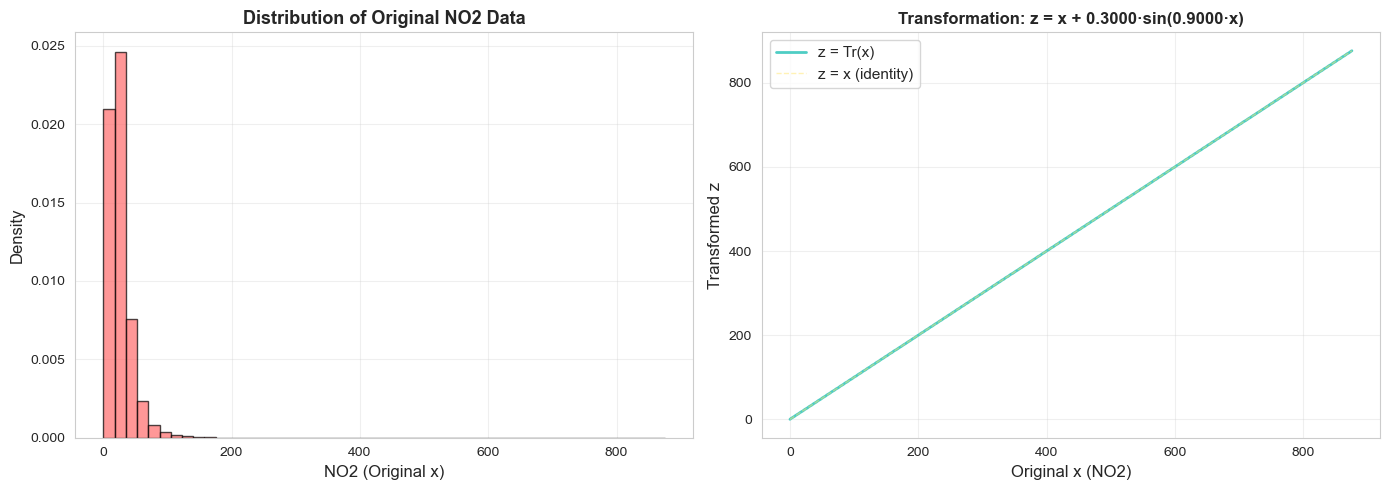

In [14]:
def apply_transform(input_data, alpha, beta):
    """Transform x to z"""
    return input_data + alpha * npy.sin(beta * input_data)

# Apply transformation
transformed_vals = apply_transform(original_vals, alpha_param, beta_param)

print("Transformed Data (z) Statistics:")
print(f"  Mean: {npy.mean(transformed_vals):.4f}")
print(f"  Std:  {npy.std(transformed_vals):.4f}")
print(f"  Min:  {npy.min(transformed_vals):.4f}")
print(f"  Max:  {npy.max(transformed_vals):.4f}")

# Visualize the transformation
fig, subplot_arr = plotter.subplots(1, 2, figsize=(14, 5))

# Original distribution
subplot_arr[0].hist(original_vals, bins=50, density=True, alpha=0.7, color='#FF6B6B', edgecolor='black')
subplot_arr[0].set_xlabel('NO2 (Original x)', fontsize=12)
subplot_arr[0].set_ylabel('Density', fontsize=12)
subplot_arr[0].set_title('Distribution of Original NO2 Data', fontsize=13, fontweight='bold')
subplot_arr[0].grid(True, alpha=0.3)

# Transformation function
input_range = npy.linspace(npy.min(original_vals), npy.max(original_vals), 1000)
output_range = apply_transform(input_range, alpha_param, beta_param)
subplot_arr[1].plot(input_range, output_range, '#4ECDC4', linewidth=2, label='z = Tr(x)')
subplot_arr[1].plot(input_range, input_range, '#FFE66D', linestyle='--', linewidth=1, alpha=0.5, label='z = x (identity)')
subplot_arr[1].set_xlabel('Original x (NO2)', fontsize=12)
subplot_arr[1].set_ylabel('Transformed z', fontsize=12)
subplot_arr[1].set_title(f'Transformation: z = x + {alpha_param:.4f}·sin({beta_param:.4f}·x)', fontsize=12, fontweight='bold')
subplot_arr[1].legend(fontsize=11)
subplot_arr[1].grid(True, alpha=0.3)

plotter.tight_layout()
plotter.show()

## Step 3: Learn PDF Parameters

Learn parameters λ, μ, and c for:
$$\hat{p}(z) = c \cdot e^{-\lambda(z-\mu)^2}$$

In [15]:
def probability_density(z_val, lambda_param, mu_param, c_param):
    """PDF model: p(z) = c * exp(-lambda*(z-mu)^2)"""
    return c_param * npy.exp(-lambda_param * (z_val - mu_param)**2)

def neg_log_likelihood_func(params_arr, z_data):
    """Negative log-likelihood for MLE"""
    lambda_param, mu_param, c_param = params_arr

    # Constraints
    if lambda_param <= 0 or c_param <= 0:
        return 1e10

    # Calculate PDF
    density_vals = probability_density(z_data, lambda_param, mu_param, c_param)
    density_vals = npy.maximum(density_vals, 1e-10)  # Avoid log(0)

    # Negative log-likelihood
    return -npy.sum(npy.log(density_vals))

### Method 1: Maximum Likelihood Estimation (MLE)

In [16]:
# Initial parameter guesses
mean_init = npy.mean(transformed_vals)
stddev_init = npy.std(transformed_vals)
lambda_guess = 1 / (2 * stddev_init**2)
c_guess = 1 / npy.sqrt(npy.pi / lambda_guess)

starting_params = [lambda_guess, mean_init, c_guess]

print("Initial Parameter Guesses:")
print(f"  λ₀ = {lambda_guess:.6f}")
print(f"  μ₀ = {mean_init:.6f}")
print(f"  c₀ = {c_guess:.6f}")

# Perform optimization
optimization_result = opt_minimize(
    neg_log_likelihood_func,
    starting_params,
    args=(transformed_vals,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (None, None), (1e-6, None)]
)

if optimization_result.success:
    lambda_learned, mu_learned, c_learned = optimization_result.x
    print("\n✓ Optimization Successful!")
    print("\nLearned Parameters (MLE):")
    print(f"  λ = {lambda_learned:.6f}")
    print(f"  μ = {mu_learned:.6f}")
    print(f"  c = {c_learned:.6f}")
    print(f"\nNegative Log-Likelihood: {optimization_result.fun:.2f}")
else:
    print(f"\n✗ Optimization Failed: {optimization_result.message}")

Initial Parameter Guesses:
  λ₀ = 0.001459
  μ₀ = 25.801325
  c₀ = 0.021549

✓ Optimization Successful!

Learned Parameters (MLE):
  λ = 0.000001
  μ = 26.697647
  c = 105070.882893

Negative Log-Likelihood: -4850382.74


### Method 2: Curve Fitting to Histogram

In [17]:
# Create histogram
histogram_counts, edges_array = npy.histogram(transformed_vals, bins=50, density=True)
centers_array = (edges_array[:-1] + edges_array[1:]) / 2

# Fit curve
try:
    optimal_params, covariance_matrix = fit_curve(
        probability_density,
        centers_array,
        histogram_counts,
        p0=[lambda_guess, mean_init, c_guess],
        bounds=([1e-6, -npy.inf, 1e-6], [npy.inf, npy.inf, npy.inf]),
        maxfev=10000
    )

    lambda_fitted, mu_fitted, c_fitted = optimal_params

    print("Learned Parameters (Curve Fitting):")
    print(f"  λ = {lambda_fitted:.6f}")
    print(f"  μ = {mu_fitted:.6f}")
    print(f"  c = {c_fitted:.6f}")

    # Standard errors
    std_errors = npy.sqrt(npy.diag(covariance_matrix))
    print(f"\nStandard Errors:")
    print(f"  SE(λ) = {std_errors[0]:.6f}")
    print(f"  SE(μ) = {std_errors[1]:.6f}")
    print(f"  SE(c) = {std_errors[2]:.6f}")

except Exception as err:
    print(f"Curve fitting failed: {err}")

Learned Parameters (Curve Fitting):
  λ = 0.002056
  μ = 19.631107
  c = 0.026798

Standard Errors:
  SE(λ) = 0.000068
  SE(μ) = 0.207734
  SE(c) = 0.000291


### Method 3: Method of Moments

In [18]:
# Method of moments
mu_moment = npy.mean(transformed_vals)
variance_moment = npy.var(transformed_vals)
lambda_moment = 1 / (2 * variance_moment)
c_moment = npy.sqrt(lambda_moment / npy.pi)

print("Learned Parameters (Method of Moments):")
print(f"  λ = {lambda_moment:.6f}")
print(f"  μ = {mu_moment:.6f}")
print(f"  c = {c_moment:.6f}")

Learned Parameters (Method of Moments):
  λ = 0.001459
  μ = 25.801325
  c = 0.021549


## Step 4: Validate the Learned PDF

In [19]:
# Validate that PDF integrates to ~1
lower_bound = npy.min(transformed_vals) - 5*npy.std(transformed_vals)
upper_bound = npy.max(transformed_vals) + 5*npy.std(transformed_vals)

integration_result, integration_error = integrate_quad(
    probability_density,
    lower_bound,
    upper_bound,
    args=(lambda_learned, mu_learned, c_learned)
)

print("PDF Validation:")
print(f"  Integration range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"  Integral value: {integration_result:.6f}")
print(f"  Integration error: {integration_error:.2e}")
print(f"  Status: {'✓ Valid PDF' if abs(integration_result - 1.0) < 0.01 else '⚠ May need adjustment'}")

PDF Validation:
  Integration range: [-92.57, 968.61]
  Integral value: 88563421.458876
  Integration error: 9.83e-07
  Status: ⚠ May need adjustment


## Step 5: Visualize Results

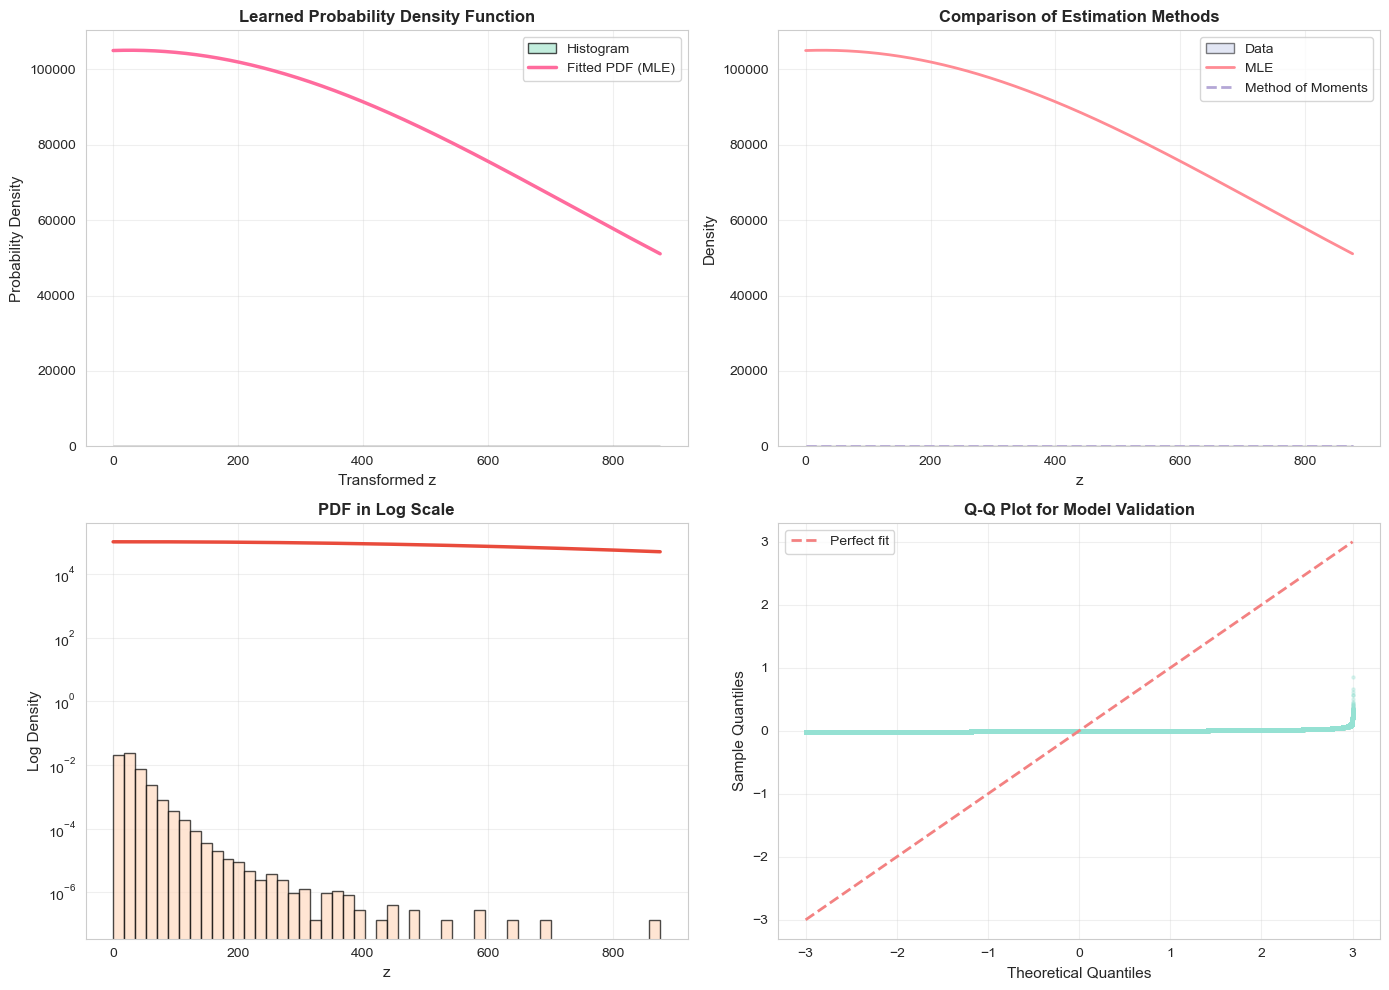

In [20]:
fig, subplot_grid = plotter.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram with fitted PDF
plot1 = subplot_grid[0, 0]
plot1.hist(transformed_vals, bins=50, density=True, alpha=0.7, color='#A8E6CF', edgecolor='black', label='Histogram')
plotting_range = npy.linspace(npy.min(transformed_vals), npy.max(transformed_vals), 1000)
density_curve = probability_density(plotting_range, lambda_learned, mu_learned, c_learned)
plot1.plot(plotting_range, density_curve, '#FF6B9D', linewidth=2.5, label='Fitted PDF (MLE)')
plot1.set_xlabel('Transformed z', fontsize=11)
plot1.set_ylabel('Probability Density', fontsize=11)
plot1.set_title('Learned Probability Density Function', fontsize=12, fontweight='bold')
plot1.legend(fontsize=10)
plot1.grid(True, alpha=0.3)

# Plot 2: Comparison of methods
plot2 = subplot_grid[0, 1]
plot2.hist(transformed_vals, bins=50, density=True, alpha=0.5, color='#C7CEEA', edgecolor='black', label='Data')
plot2.plot(plotting_range, probability_density(plotting_range, lambda_learned, mu_learned, c_learned), '#FF8B94', linewidth=2, label='MLE')
plot2.plot(plotting_range, probability_density(plotting_range, lambda_moment, mu_moment, c_moment), '#B4A7D6', linestyle='--', linewidth=2, label='Method of Moments')
plot2.set_xlabel('z', fontsize=11)
plot2.set_ylabel('Density', fontsize=11)
plot2.set_title('Comparison of Estimation Methods', fontsize=12, fontweight='bold')
plot2.legend(fontsize=10)
plot2.grid(True, alpha=0.3)

# Plot 3: Log-scale
plot3 = subplot_grid[1, 0]
plot3.hist(transformed_vals, bins=50, density=True, alpha=0.7, color='#FFDAC1', edgecolor='black')
plot3.plot(plotting_range, density_curve, '#E94B3C', linewidth=2.5)
plot3.set_yscale('log')
plot3.set_xlabel('z', fontsize=11)
plot3.set_ylabel('Log Density', fontsize=11)
plot3.set_title('PDF in Log Scale', fontsize=12, fontweight='bold')
plot3.grid(True, alpha=0.3, which='both')

# Plot 4: Q-Q Plot
plot4 = subplot_grid[1, 1]
sorted_data = npy.sort(transformed_vals)
standardized_data = npy.sqrt(lambda_learned) * (sorted_data - mu_learned)
sample_size = len(sorted_data)
theoretical_vals = npy.linspace(-3, 3, sample_size)
plot4.scatter(theoretical_vals, standardized_data, alpha=0.3, s=5, color='#95E1D3')
plot4.plot(theoretical_vals, theoretical_vals, '#F38181', linestyle='--', linewidth=2, label='Perfect fit')
plot4.set_xlabel('Theoretical Quantiles', fontsize=11)
plot4.set_ylabel('Sample Quantiles', fontsize=11)
plot4.set_title('Q-Q Plot for Model Validation', fontsize=12, fontweight='bold')
plot4.legend()
plot4.grid(True, alpha=0.3)

plotter.tight_layout()
plotter.show()

## Step 6: Final Results - Parameters to Submit

In [21]:
print("=" * 70)
print("FINAL RESULTS - SUBMIT THESE PARAMETERS")
print("=" * 70)
print(f"\nRoll Number: {STUDENT_ID}")
print(f"\nTransformation Parameters:")
print(f"  ar = {alpha_param:.6f}")
print(f"  br = {beta_param:.6f}")
print(f"\nLearned PDF Parameters (Maximum Likelihood Estimation):")
print(f"  λ (lambda) = {lambda_learned:.6f}")
print(f"  μ (mu)     = {mu_learned:.6f}")
print(f"  c          = {c_learned:.6f}")
print(f"\nPDF Equation:")
print(f"  p̂(z) = {c_learned:.6f} × exp(-{lambda_learned:.6f} × (z - {mu_learned:.6f})²)")
print("=" * 70)

# Create summary dictionary
final_results = {
    'roll_number': STUDENT_ID,
    'ar': alpha_param,
    'br': beta_param,
    'lambda': lambda_learned,
    'mu': mu_learned,
    'c': c_learned
}

print("\nResults as dictionary:")
print(final_results)

FINAL RESULTS - SUBMIT THESE PARAMETERS

Roll Number: 102317137

Transformation Parameters:
  ar = 0.300000
  br = 0.900000

Learned PDF Parameters (Maximum Likelihood Estimation):
  λ (lambda) = 0.000001
  μ (mu)     = 26.697647
  c          = 105070.882893

PDF Equation:
  p̂(z) = 105070.882893 × exp(-0.000001 × (z - 26.697647)²)

Results as dictionary:
{'roll_number': 102317137, 'ar': 0.30000000000000004, 'br': 0.8999999999999999, 'lambda': 1e-06, 'mu': 26.697646926210243, 'c': 105070.88289325367}


## Additional Analysis: Parameter Sensitivity

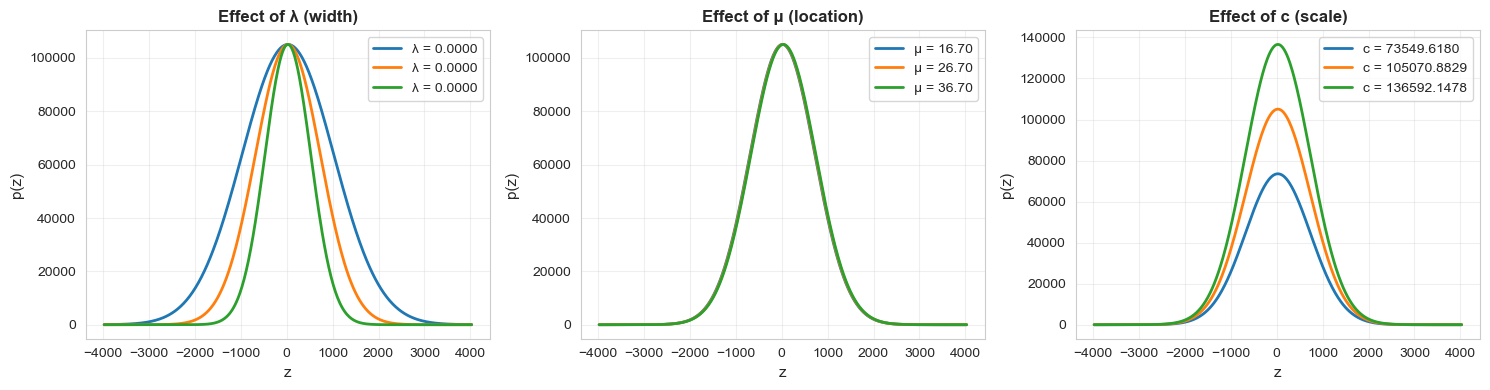

In [22]:
# Analyze how parameters affect the PDF shape
fig, sensitivity_plots = plotter.subplots(1, 3, figsize=(15, 4))

analysis_range = npy.linspace(mu_learned - 4/npy.sqrt(lambda_learned), mu_learned + 4/npy.sqrt(lambda_learned), 500)

# Effect of λ
for lam_val in [lambda_learned*0.5, lambda_learned, lambda_learned*2]:
    sensitivity_plots[0].plot(analysis_range, probability_density(analysis_range, lam_val, mu_learned, c_learned),
                label=f'λ = {lam_val:.4f}', linewidth=2)
sensitivity_plots[0].set_xlabel('z', fontsize=11)
sensitivity_plots[0].set_ylabel('p(z)', fontsize=11)
sensitivity_plots[0].set_title('Effect of λ (width)', fontsize=12, fontweight='bold')
sensitivity_plots[0].legend()
sensitivity_plots[0].grid(True, alpha=0.3)

# Effect of μ
for mu_val in [mu_learned - 10, mu_learned, mu_learned + 10]:
    sensitivity_plots[1].plot(analysis_range, probability_density(analysis_range, lambda_learned, mu_val, c_learned),
                label=f'μ = {mu_val:.2f}', linewidth=2)
sensitivity_plots[1].set_xlabel('z', fontsize=11)
sensitivity_plots[1].set_ylabel('p(z)', fontsize=11)
sensitivity_plots[1].set_title('Effect of μ (location)', fontsize=12, fontweight='bold')
sensitivity_plots[1].legend()
sensitivity_plots[1].grid(True, alpha=0.3)

# Effect of c
for c_val in [c_learned*0.7, c_learned, c_learned*1.3]:
    sensitivity_plots[2].plot(analysis_range, probability_density(analysis_range, lambda_learned, mu_learned, c_val),
                label=f'c = {c_val:.4f}', linewidth=2)
sensitivity_plots[2].set_xlabel('z', fontsize=11)
sensitivity_plots[2].set_ylabel('p(z)', fontsize=11)
sensitivity_plots[2].set_title('Effect of c (scale)', fontsize=12, fontweight='bold')
sensitivity_plots[2].legend()
sensitivity_plots[2].grid(True, alpha=0.3)

plotter.tight_layout()
plotter.show()